In [6]:
!pip install prophet

In [7]:

import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

In [8]:
import pandas as pd
df = pd.read_csv("/content/train.csv.zip")
print(df.head())
print(df.columns)

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

convert date coln


In [9]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

print(df.dtypes)

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date                object
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object


In [10]:
daily_sales = df.groupby(
    'Order Date'
)['Sales'].sum().reset_index()

daily_sales.columns = ['ds','y']

daily_sales.head()

,ds,y
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [11]:
print(daily_sales.shape)

daily_sales.describe()

(1230, 2)


,ds,y
count,1230,1230.000000
mean,2017-01-21 12:17:33.658536704,1838.647791
min,2015-01-03 00:00:00,2.025000
25%,2016-01-09 06:00:00,378.519000
50%,2017-02-04 12:00:00,1058.397000
75%,2018-01-20 18:00:00,2382.217000
max,2018-12-30 00:00:00,28106.716000
std,NaN,2295.418267


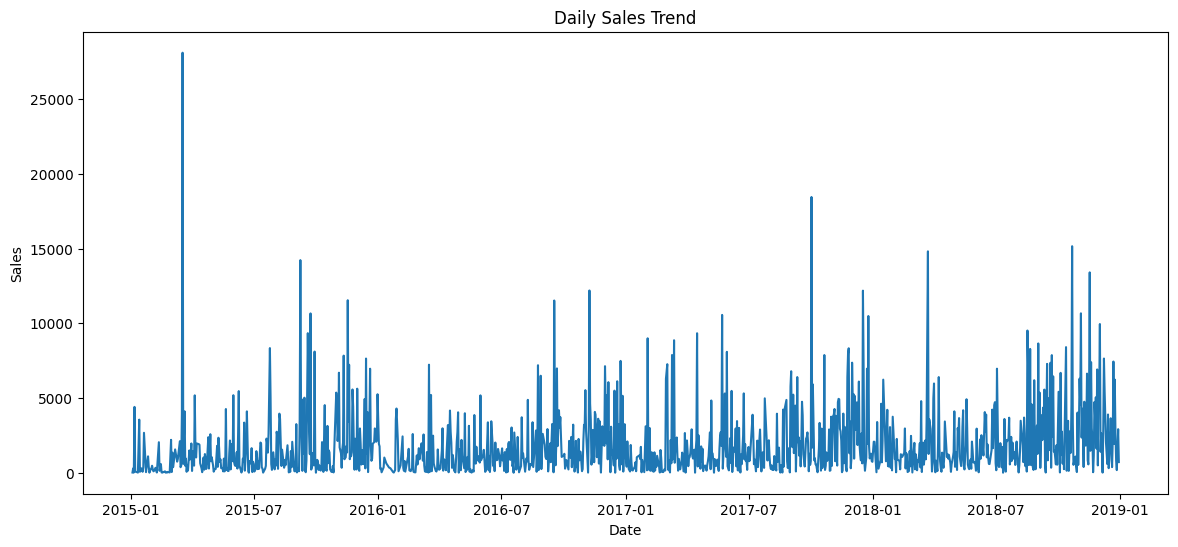

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    daily_sales['ds'],
    daily_sales['y']
)

plt.title('Daily Sales Trend')

plt.xlabel('Date')

plt.ylabel('Sales')

plt.show()

Train forecast model

In [13]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(daily_sales)

Forecast next 90 days

In [14]:
future = model.make_future_dataframe(
    periods=90
)

forecast = model.predict(future)

In [15]:
forecast[
    ['ds','yhat','yhat_lower','yhat_upper']
].tail(20)

,ds,yhat,yhat_lower,yhat_upper
1300,2019-03-11,2680.232147,58.526642,5336.225135
1301,2019-03-12,3092.010735,324.789108,5703.180008
1302,2019-03-13,2672.683611,-140.110920,5449.591895
1303,2019-03-14,2133.581728,-569.193899,4944.144913
1304,2019-03-15,2778.613796,148.925226,5371.110320
1305,2019-03-16,3231.836491,502.465996,6124.461807
1306,2019-03-17,2998.437139,242.196419,5692.148525
1307,2019-03-18,2882.380700,224.622232,5645.839217
1308,2019-03-19,3217.015786,343.578182,6016.840598
1309,2019-03-20,2721.992702,124.300538,5555.977661


plotting forecast

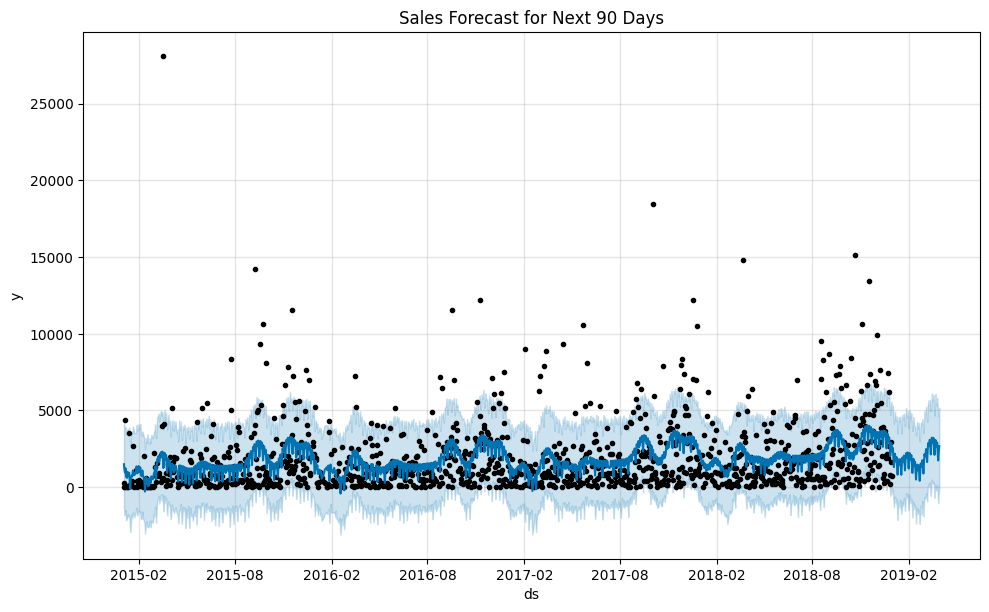

In [16]:
fig = model.plot(forecast)

plt.title("Sales Forecast for Next 90 Days")

plt.show()

Trend Analysis

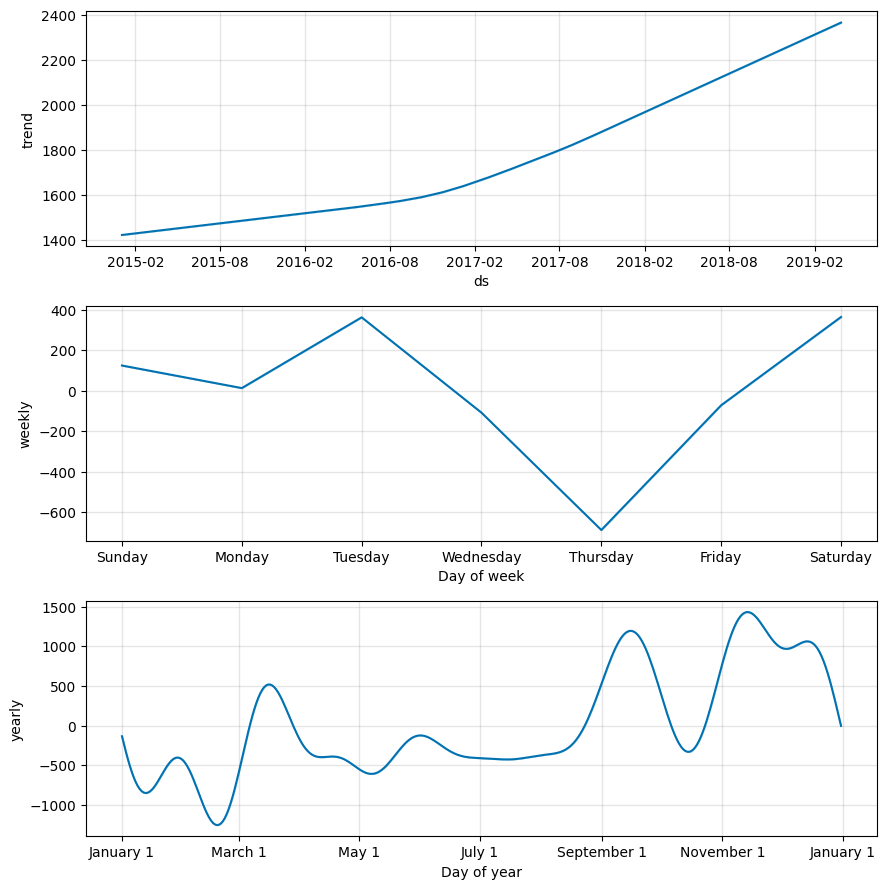

In [17]:
fig2 = model.plot_components(
    forecast
)

plt.show()

calculating RMSE

In [18]:
train = daily_sales[:-90]

test = daily_sales[-90:]

In [19]:
model = Prophet()

model.fit(train)

future = model.make_future_dataframe(
    periods=90
)

forecast = model.predict(future)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [20]:
from sklearn.metrics import mean_squared_error
import numpy as np

pred = forecast['yhat'].tail(90)

rmse = np.sqrt(
    mean_squared_error(
        test['y'],
        pred
    )
)

print("RMSE:", rmse)

RMSE: 3069.4450294867556


In [21]:
forecast.to_csv(
    'sales_forecast.csv',
    index=False
)

ADDITIONAL EDA

SALES BY CATEGORY

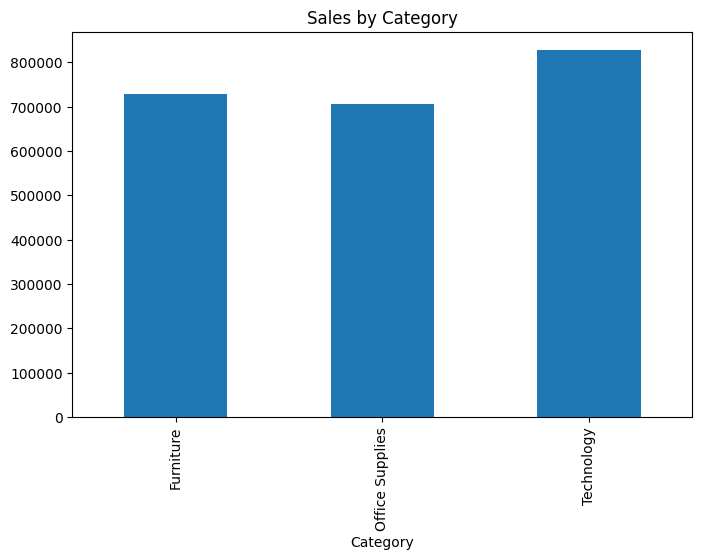

In [22]:
category_sales = df.groupby(
    'Category'
)['Sales'].sum()

category_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Sales by Category')

plt.show()

SALES BY REGION

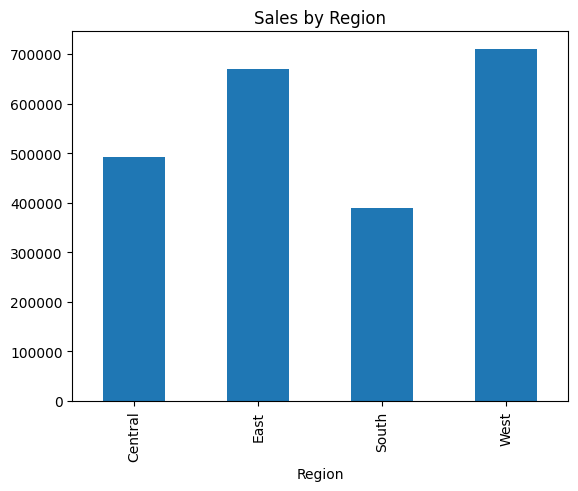

In [23]:
region_sales = df.groupby(
    'Region'
)['Sales'].sum()

region_sales.plot(
    kind='bar'
)

plt.title('Sales by Region')

plt.show()

MONTHLY SALES TREND

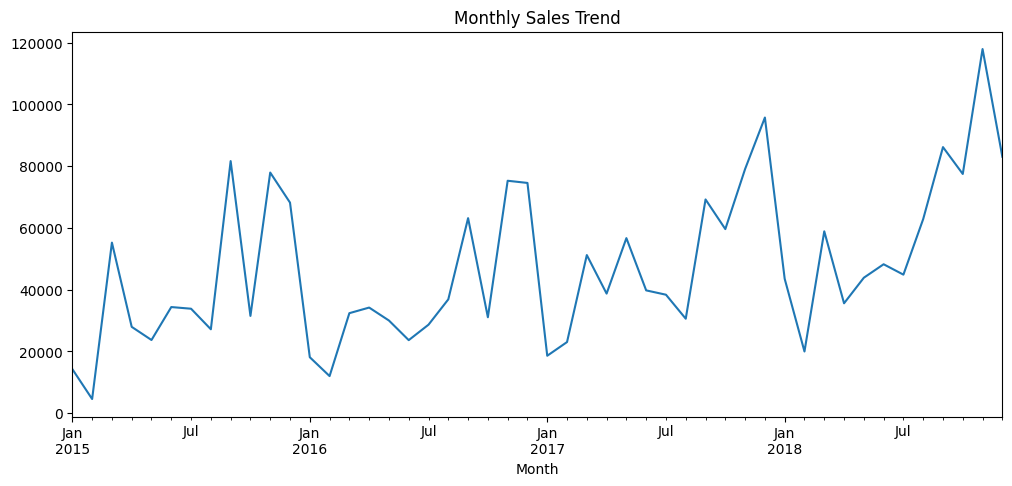

In [24]:
monthly_sales = df.copy()

monthly_sales['Month'] = monthly_sales[
    'Order Date'
].dt.to_period('M')

monthly_sales = monthly_sales.groupby(
    'Month'
)['Sales'].sum()

monthly_sales.plot(
    figsize=(12,5)
)

plt.title("Monthly Sales Trend")

plt.show()

IMPROVISATION

Add Multiplicative Seasonality

In [25]:
model = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=True
)

Remove Extreme Outliers

In [26]:
Q1 = daily_sales['y'].quantile(0.25)
Q3 = daily_sales['y'].quantile(0.75)

IQR = Q3 - Q1

daily_sales_clean = daily_sales[
    (daily_sales['y'] >= Q1 - 1.5*IQR) &
    (daily_sales['y'] <= Q3 + 1.5*IQR)
]

RE TRAINING

In [27]:
train = daily_sales_clean[:-90]

test = daily_sales_clean[-90:]

In [28]:
from prophet import Prophet

model = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=True
)

model.fit(train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [29]:
future = model.make_future_dataframe(
    periods=90
)

forecast = model.predict(future)

CALCULATING NEW RMSE

In [30]:
from sklearn.metrics import mean_squared_error
import numpy as np

pred = forecast['yhat'].tail(90)

rmse = np.sqrt(
    mean_squared_error(
        test['y'],
        pred
    )
)

print("New RMSE:", rmse)

New RMSE: 1640.7038116419956


In [32]:
monthly_sales = df.groupby(
    pd.Grouper(key='Order Date', freq='ME')
)['Sales'].sum().reset_index()

monthly_sales.columns = ['ds', 'y']

monthly_sales.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


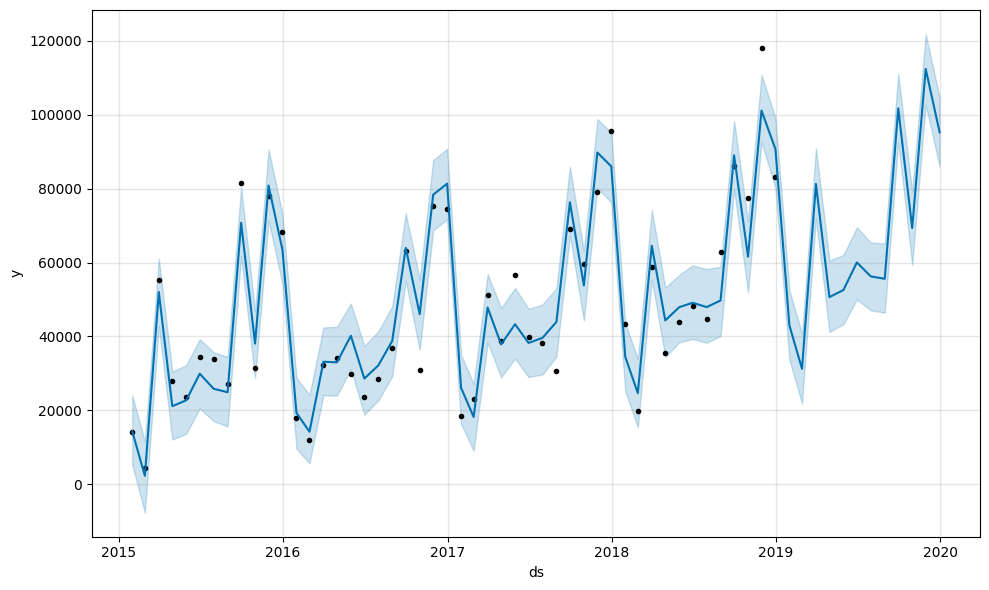

In [33]:
model = Prophet()
model.fit(monthly_sales)

future = model.make_future_dataframe(
    periods=12,
    freq='ME'
)

forecast = model.predict(future)

model.plot(forecast)
plt.show()

CALCULATING MAE

In [34]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    test['y'],
    pred
)

print("MAE:", mae)

MAE: 1375.3750508981311
